# XX. Summary of germination models

## Week 13/2026

_Boyan Mihaylov, MSc Computational Science (UVA/VU)_

This notebook provides a systematic summary of all diffusion-driven germination models in the study. Furthermore, a reparameterisation framework is presented for their simplification.

## 1. Geometric variables

A spore is idealised as a sphere with a radius $r_s$, a surface area $A_s=4\pi r_s^2$ and a volume $V_s=4/3 \pi r_s^3$. The cell wall can be viewed as the outermost shell of this sphere, consisting of two thinner shells: an outer, hydrophobin-rich layer with a thickness $h_\textrm{hp}$ and an inner, polysaccharide-rich layer with a thickness $h_{\textrm{ps}}$.

The volume of the inner cell wall is considered the main compartment of inducer saturation. The total volume can be calculated as

$$
V_{\textrm{ps}}=\frac{4}{3}\pi\left[(r_s-d_{\textrm{hp}})^3-(r_s-d_{\textrm{hp}}-d_{\textrm{ps}})^3\right],
$$

which reflects the subtraction of the protoplast (membrane included) from the internal volume without the outer cell wall. Since the thickness of the hydrophobin layer is determined by the size of the hydrophobin rodlets, it can be considered nearly constant. On the other hand, the spore radius and the inner cell wall may exhibit much larger variations. For this reason, the spore radius $r_s$ can be modelled by a normally distributed random variable $R$ with a mean $\mu_R$ and a standard deviation $\sigma_R$. Similarly, the inner cell wall thickness can be modelled by a random variable $H$ with a mean $\mu_H$ and a standard deviation $\sigma_H$. It is important to consider that the inducer can occupy at most only the vacant fraction of the total volume, which according to studies[1] is approximately 24%. Thus, the expression for the effective inner cell wall volume becomes

$$
V_{\textrm{ps, eff}}=0.24\frac{4}{3}\pi\left[(R-d_{\textrm{hp}})^3-(R-d_{\textrm{hp}}-H)^3\right].
$$

Similarly, the other geometric variables can incorporate the random spore radius:

$$
A_s=4\pi R^2,
$$

$$
V_s=4/3 \pi R^3.
$$

Assuming that spores at an inoculum density of $\rho_s$ are positioned in a regular grid, a designated volume per spore can be defined as

$$
\begin{equation}
V_{\textrm{des}}=\frac{1}{\rho_s}.
\end{equation}
$$

Even if molecules diffuse over its boundaries into adjacent volumes, this occurs in a symmetric fashion, so that the net quantity of molecules within a volume remains preserved. Consecutively, one can separate this volume into the space occupied by the spore, $V_s$, and that remaining for the medium, $V_{\textrm{free}}=V_{\textrm{des}}-V_s$. A volume fraction, denoting the percentage per unit volume occupied by the conidia, can be defined as $\phi=\rho_s V_s$.

## 2. Main molecular components

Germination is considered to be primarily dependent on two molecular actors - an inhibitor $\textrm{I}$ (e.g. 1-octen-3-ol) and an inducer $\textrm{C}$ (e.g. alanine). There are 4 relevant types of concentration:
- $c_{\textrm{in}}^{\textrm{I}}$ - concentration of inhibitor in the interior side of the cell wall;
- $c_{\textrm{out}}^{\textrm{I}}$ - concentration of inhibitor in the extracellular medium;
- $c_{\textrm{in}}^{\textrm{C}}$ - concentration of inducer in the interior side of the cell wall;
- $c_{\textrm{out}}^{\textrm{C}}$ - concentration of inducer in the extracellular medium.

At inoculation, the interior concentration of inhibitor is defined as

$$
c_{\textrm{in}}^{\textrm{I}}(t=0)=c_0.
$$

Furthermore, any exterior concentration of inhibitor present at inoculation is defined as

$$
c_{\textrm{out}}^{\textrm{I}}(t=0)=c_{\textrm{ex}}^{\textrm{I}}.
$$

In most cases in this study, $c_{\textrm{ex}}^{\textrm{I}}=0$.

The inhibitor molecules strive to equilibrate across the cell wall. Taking into account the density of spores as sources of inhibitor dispersal, the internal inhibitor concentration at any spore over time can be calculated as

$$
c_{\textrm{in}}^{\textrm{I}}(t)=\left[\phi+(1-\phi)e^{-\frac{t}{\tau(1-\phi)}}\right] c_0+(1-\phi)\left(1-e^{-\frac{t}{\tau^{\textrm{I}}(1-\phi)}}\right)c_{\textrm{ex}}^{\textrm{I}}
$$

or simply

$$
c_{\textrm{in}}^{\textrm{I}}(t)=\left[\phi+(1-\phi)e^{-\frac{t}{\tau^{\textrm{I}}(1-\phi)}}\right] c_0
$$

if $c_{\textrm{ex}}^{\textrm{I}}=0$. The two important variables here are the volume fraction $\phi$ and

$$
\tau^{\textrm{I}}=\frac{V_s}{P_{\textrm{eff}}^{\textrm{I}}A_s},
$$

which is a characteristic permeation time related to the volume to surface area ratio of the spore and the effective permeation constant $P_{\textrm{eff}}^{\textrm{I}}$ of the inhibitor, valid for the entire cell wall complex. 

A picture of the induction mechanism may be more accurately painted using the available knowledge about carbon-sensitive receptor proteins tethered to the cell membrane. This supports the representation of the inner cell wall as an inducer-soaking compartment, with the outer cell wall being a diffusion-limiting barrier. In the inhibitor case, however, the situation is different. Since there is insufficient evidence for the exact locations where the inhibitor originates and exerts its effect, it is harder to generalise which volumes are relevant for its concentration equilibration and which cell wall layers should be considered in the permeation between spore and medium. Therefore, the full spore volume and area ($V_s$ and $A_s$) are taken as approximate reference and $P_{\textrm{eff}}^{\textrm{I}}$ may account for any number of diffusion-limiting barriers: the cell membrane, the inner cell wall, the hydrophobin layer. In any combination of $M$ of these layers, the permeability is computed through the expression

$$
\frac{1}{P_{\textrm{eff}}^{\textrm{I}}}=\sum_i^M{\frac{1}{P_i^{\textrm{I}}}}.
$$

Contrary to this, the equilibration of inducer concentration over the hydrophobin barrier only takes into account a permeation constant $P_{\textrm{eff}}^{\textrm{C}}$ of the inducer molecule through the rodlet layer and obeys the formula

$$
c_{\textrm{in}}^{\textrm{C}}{(t)}=c_{\textrm{ex}}^{\textrm{C}}(1-e^{-t/\tau^{\textrm{C}}}),
$$

where $c_{\textrm{ex}}^{\textrm{C}}$ is the initial external inducer concentration (considered effectively constant) and

$$
\begin{equation}
\tau^{\textrm{C}}=\frac{V_{\textrm{ps, eff}}}{P_s^{\textrm{C}}A_s},
\end{equation}
$$

i.e. the characteristic permeation time is dependent on the inner cell wall compartment and not on the entire spore volume.

## 3. Germination mechanisms

Under the general assumption that both the release of inhibition and a strong enough inducing signal must be present for germination, the break of dormancy can be expressed as an instantaneous event that depends on a twofold criterion:

$$
c_{\textrm{in}}^{\textrm{I}}(t) < \gamma c_0^{\textrm{I}} \quad \textrm{and} \quad s\left(c_{\textrm{in}}^{\textrm{C}}(t)\right) > \omega.
$$

The first criterion states that germination becomes possible when the internal inhibitor concentration is below a certain fraction $\gamma$ (with $0<\gamma<1$) of its initial concentration. By specifying

$$
c_{\textrm{in}}^{\textrm{I}}(t) = \beta c_0,
$$

where

$$
\beta=\phi+(1-\phi)e^{-\frac{t}{\tau(1-\phi)}},
$$

one can simplify the criterion as

$$
\beta < \gamma.
$$

It is natural to assume that the threshold value $\gamma$ is not universal for all spores but rather depends on a complex network of factors, which can be reflected by modelling it as a Normal random variable $X$, with mean $\mu_X$ and standard deviation $\sigma_X$.

The second criterion enables germination when an inducing signal produced by the inducer concentration inside the outer cell wall becomes larger than a certain threshold $\omega$ (with $0<\omega<1$) of the outside concentration (which for simplicity is considered constant). Due to the known mechanisms of ligation to receptor molecules, the inducing effect is not linear with the concentration but can be assumed to follow Michaelis-Menten dynamics:

$$
s\left(c_{\textrm{in}}^{\textrm{C}}(t)\right)=s_{\textrm{max}} \frac{c_{\textrm{in}}^\textrm{C}(t)}{K_s^\textrm{C}+c_{\textrm{in}}^\textrm{C}(t)}
$$

with a saturation level $s_{\textrm{max}}$ (set to $1$ to normalize the signal against the threshold) and a half-saturation constant $K_s^\textrm{C}$.

Such an assumption could not be made for the inhibitor due to lack of evidence, hence its simpler formulation. On the other hand, the inducer condition does not allow analogical cancellations (e.g. of $c_{\textrm{ex}}^{\textrm{C}}$), so we keep the full inequality expression.

Once again, the threshold $\omega$ may be influenced by many factors, so it is best modelled by a Normal random variable $Y$ with mean $\mu_Y$ and standard deviation $\sigma_Y$.

In the simplest case, when the inhibitor and inducer are non-interacting, the probability of a spore germinating at a given time can be expressed as

$$
p(t) = \mathbb{P}{(\beta < X \: \cap \: \psi > Y \: | \: \rho_s, t)}=\int_0^{\infty}{\int_0^{\infty}{\left[1-F_X{(\beta)}\right]\, f_R(r_s) \, F_Y{(s)} \, f_H(d_{\textrm{ps}})d{r_s}}d{d_{\textrm{ps}}}},
$$

where

$$
F_X{(\beta)}=\Phi{\left(\frac{\beta(r_s, t)-\mu_X}{\sigma_X}\right)}
$$

and

$$
F_Y{(s)}=\Phi{\left(\frac{s(K_s^\textrm{C}, r_s, d_{\textrm{ps}}, t)-\mu_Y}{\sigma_Y}\right)}
$$

are cumulative distribution functions,

$$
f_R(r_s) = \frac{1}{\sqrt{2\pi}\sigma_R}\exp{\left(-\frac{(r_s-\mu_R)}{2\sigma_R^2}\right)}
$$

and

$$
f_H(d_{\textrm{ps}}) = \frac{1}{\sqrt{2\pi}\sigma_H}\exp{\left(-\frac{(d_{\textrm{ps}}-\mu_H)}{2\sigma_H^2}\right)}
$$

are Normal probability density functions, and a separate integral is taken over all possible values for the two random variables $R$ and $H$.

A constrain is imposed on all random variable parameters that their standard deviation must not exceed the order of the mean, otherwise they would produce unrealistically wide distributions. Therefore, instead of manipulating the $\sigma$ parameters directly, an exponent parameter $\delta$ is assigned to each random variable distribution, such that

$$
\sigma=\mu e^{-\delta}.
$$

In summary, the free parameters of this model are $P_{\textrm{eff}}^{\textrm{I}}$, $P_{\textrm{eff}}^{\textrm{C}}$, $K_s^\textrm{C}$, $\mu_X$, $\delta_X$, $\mu_Y$ and $\delta_Y$.

## 4. Interactions

The probability expression becomes more complex once interactions between the inhibitor and the inducer come into play. Starting from the basic model, several primary nodes are pinpointed that may interact with each other:

- the inducing signal strength $s$;
- the induction threshold $\omega$;
- the inhibition threshold $\gamma$;
- the cell wall permeability for inducer and inhibitor molecules.

This enables outlining the following interactions of interest, labelled by capital letters:

- ($\textrm{A}$) the inducer causes an increased cell wall permeability (aligned with dormancy-breaking processes in spores), making it easier for inducing molecules to reach the membrane-bound receptors and for inducer molecules to deplete.
- ($\textrm{B}$) the inducer increases the inhibition threshold by promoting (via mass-action dynamics) an effect that makes the spore less succeptible to inhibition;
- ($\textrm{C}$) the inhibitor reduces the maximum possible signal strength, either by directly blocking the binding sites or by some other mass-action effect further down the signalling pathway (inhibitor dynamics expression multiplied with the signal strength);
- ($\textrm{D}$) the inhibitor causes a reduced cell wall permeability (aligned with observations of dormant spores), making it more difficult for inducing molecules to reach the membrane-bound receptors and for inducer molecules to deplete;
- ($\textrm{E}$) the inhibitor increases the induction threshold by promoting (via mass-action dynamics) an effect that makes it more difficult for the inducing signal to trigger germination (standard Michaelis-Menten effect added to threshold);

For the sake of completeness, all possible combinations of these effects are considered, despite the concern that multifacetted effect of the same actor on several nodes may be less biologically plausible. Furthermore, in a scenario where one actor affects the pathway of the other, the former may or may not also contribute to germination directy (e.g. an inhibitor may affect the induction threshold but also co-trigger germination by depleting under its threshold). It is up to the sensitivity analysis to determine whether the prediction power of the model in such cases is overshadowed by its increased complexity.

### 4.1. Inducer modulates permeability (A)

In this scenario, it is considered that the inducing signal arising from the concentration of the carbon source yields a transformation of the permeation constant for both the inducer and the inhibitor molecules. In its simplest formulation, this can happen as a linear offset from a base permeability for small inducer concentrations and reach a saturating permeability for high-inducer concentration $P_{\textrm{max}}$ (here heuristically set to $10^{3}\ \mu\textrm{m/s}$).

For the inducer and the inhibitor permeability, respectively:

$$
P_{\textrm{perturbed}}^{\textrm{C}}=P_{\textrm{max}}-(P_{\textrm{max}}^{\textrm{C}}-P_{\textrm{base}}^{\textrm{C}})e^{-\lambda^{\textrm{C}}s},
$$

$$
P_{\textrm{perturbed}}^{\textrm{I}}=P_{\textrm{max}}-(P_{\textrm{max}}^{\textrm{I}}-P_{\textrm{base}}^{\textrm{I}})e^{-\lambda^{\textrm{C}}s},
$$

where $\lambda^{\textrm{C}}$ controls the rate at which the permeability shifts based on the concentration-based inducing signal. If the signal additionally triggers germination by surpassing the threshold $\omega$, the half-saturation constant $K_s^\textrm{C}$ implicit in the term is the same as for the permeability-decreasing effect.

The dynamic modulation of the permeability creates a system of ODEs that does not have a closed-form solution and cannot be computed as an integral, like in the previous case. Instead, a numerical Monte Carlo integration of the differential equations is necessary to account for all possible values of the random variable distributions $R$ and $H$.

First, the simpler case is observed where the **inducer only affects the cell wall permeability** and does not directly trigger germination through a threshold-based criterion. The change of inhibitor concentration in the spore over time is given by the ODE

$$
\begin{equation}
\frac{d{c_{\textrm{in}}^{\textrm{I}}}}{d{t}}=-\left(\frac{P_{\textrm{perturbed}}^{\textrm{I}}A_s}{V_s}\right)\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

The outside concentration changes as

$$
\begin{equation}
\frac{d{c_{\textrm{out}}^{\textrm{I}}}}{d{t}}=\left(\frac{P_{\textrm{perturbed}}^{\textrm{I}}A_s}{V_{\textrm{free}}}\right)\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right].
\end{equation}
$$

The concentration drop of inducer across the outer cell wall, on the other hand, follows the formula

$$
\begin{equation}
\frac{d{\Delta c^{\textrm{C}}}}{d{t}}=-\left(\frac{P_{\textrm{perturbed}}^{\textrm{C}}A_s}{V_{\textrm{ps}}}\right)\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{out}}^{\textrm{C}}{(t)}\right],
\end{equation}
$$

Since $\Delta c^{\textrm{C}}=c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{out}}^{\textrm{C}}{(t)}$ and $c_{\textrm{out}}^{\textrm{C}}{(t)}=c_{\textrm{ex}}^{\textrm{C}}$ is a constant, this equates to

$$
\begin{equation}
\frac{d{c_{\textrm{in}}^{\textrm{C}}}}{d{t}}=-\left(\frac{P_{\textrm{perturbed}}^{\textrm{C}}A_s}{V_{\textrm{ps}}}\right)\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{ex}}^{\textrm{C}}\right].
\end{equation}
$$

Thus, the system of coupled ODEs $\dot{c}_{\textrm{in}}^{\textrm{I}}=\frac{d{\Delta c^{\textrm{I}}}}{d{t}}$, $\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{d{\Delta c^{\textrm{C}}}}{d{t}}$ and $\dot{c}_{\textrm{in}}^{\textrm{C}}=\frac{d{c_{\textrm{in}}^{\textrm{C}}}}{d{t}}$ needs to be solved. The initial conditions for these ODEs are $c_{\textrm{in}}^{\textrm{I}}{(0)}=c_0$, $c_{\textrm{out}}^{\textrm{I}}{(0)}=0$ and $c_{\textrm{in}}^{\textrm{C}}{(0)}=0$. The initial inhibitor concentration inside the spore ($c_0$) is certainly not uniform over all spores and is therefore modelled by another random variable, $O$, normally distributed with mean $\mu_O$ and standard deviation $\sigma_O$. The Monte Carlo integration must therefore also sample this distribution for possible inhibitor/inducer concentration evolutions.

At specific time points of these evolutions, the germination percentage is determined by comparing the concentrations to a sample of thresholds. If both the inhibitor and the inducer directly influence germination through a threshold mechanism, a sample is drawn from each of their respective threshold distributions. Alternatively, the inducer's role may be only indirect, in which case a sample is only drawn from the $X$ distribution.

In summary, the free parameters used in the model with a single direct influence are $P_{\textrm{eff}}^{\textrm{I}}$, $P_{\textrm{eff}}^{\textrm{C}}$, $K_s^\textrm{C}$, $\lambda^C$, $\mu_O$, $\delta_O$, $\mu_X$ and $\delta_X$. If the inducer also directly co-determines germination, $\mu_Y$ and $\delta_Y$ are added to these.

In [25]:
using CUDA
using DifferentialEquations
using OrdinaryDiffEq
using DiffEqGPU
using Distributions
using StaticArrays

# 1. Define your ODE system that works with GPU arrays
function germination_system!(du, u, p, t)
    c_in_I, c_out_I, c_in_C = u
    
    # Unpack parameters for this specific spore
    P_perturbed_I, P_perturbed_C, P_max_C, c_ex_C, A_s, V_s, V_free, V_ps = p
    
    # Compute inducing signal s from c_in_C
    K_s_C = p[9]  # Extract if needed from p
    s = c_in_C / (K_s_C + c_in_C)
    
    # Update permeability constants based on signal
    P_I_current = P_max_C - (P_max_C - P_perturbed_I) * exp(-p[10] * s)  # λ^C stored in p[10]
    P_C_current = P_max_C - (P_max_C - P_perturbed_C) * exp(-p[10] * s)
    
    # ODE equations
    du[1] = -(P_I_current * A_s / V_s) * (c_in_I - c_out_I)
    du[2] = (P_I_current * A_s / V_free) * (c_in_I - c_out_I)
    du[3] = -(P_C_current * A_s / V_ps) * (c_in_C - c_ex_C)
end

# 2. Set up batched sample generation
function generate_samples(n_samples; μ_R, σ_R, μ_H, σ_H, μ_O, σ_O, μ_X, σ_X, μ_Y, σ_Y)
    # Generate random samples for each spore
    R_samples = randn(n_samples) .* σ_R .+ μ_R
    H_samples = randn(n_samples) .* σ_H .+ μ_H
    O_samples = randn(n_samples) .* σ_O .+ μ_O
    X_samples = randn(n_samples) .* σ_X .+ μ_X
    Y_samples = randn(n_samples) .* σ_Y .+ μ_Y
    
    return (R=R_samples, H=H_samples, O=O_samples, X=X_samples, Y=Y_samples)
end

# 3. Compute geometry for each sample
function compute_geometry(r_s, h_ps, d_hp)
    A_s = 4π * r_s^2
    V_s = (4/3) * π * r_s^3
    V_ps_eff = 0.24 * (4/3) * π * ((r_s - d_hp)^3 - (r_s - d_hp - h_ps)^3)
    return (A_s=A_s, V_s=V_s, V_ps_eff=V_ps_eff)
end

# Replace the @cuda kernel with this function
function solve_batch_gpu!(
    germinated::CuArray{Bool}, 
    germination_times::CuArray{Float32},
    samples_gpu, 
    t_span, 
    ρ_s::Float64, 
    d_hp::Float64, 
    c_ex_C::Float64,
    P_eff_I_base, 
    P_s_C_base, 
    K_s_C, 
    λ_C, 
    P_max, 
    γ, 
    ω
)
    
    n_samples = length(samples_gpu.R)
    
    # Wrapper to capture parameters into the ODE function
    function make_ode_func(R, H, O, X, Y)
        function ode!(du, u, p, t)
            germination_system!(du, u, p, t)
        end
        return ode!
    end
    
    # Wrapper to create problem for each sample
    function prob_func(prob, i, repeat)
        # Extract parameters for this sample
        R = samples_gpu.R[i]
        H = samples_gpu.H[i]
        O = samples_gpu.O[i]
        X = samples_gpu.X[i]
        Y = samples_gpu.Y[i]
        
        # Compute germination-specific parameters
        # (These depend on the sampled values R, H, O, X, Y)
        P_perturbed_I = P_eff_I_base * (1.0f0 + Float32(γ) * Float32(O))
        P_perturbed_C = P_s_C_base * (1.0f0 + Float32(γ) * Float32(X))
        
        # Compute geometry
        geom = compute_geometry(Float32(R), Float32(H), Float32(d_hp))
        
        # Effective volumes
        V_free = (1.0f0 - 0.24f0) * geom.V_s
        
        # Initial conditions
        c_in_I_0 = 0.0f0
        c_out_I_0 = 1.0f0
        c_in_C_0 = 0.0f0
        u0 = @SVector [c_in_I_0, c_out_I_0, c_in_C_0]
        
        # Parameters tuple
        p_sample = @SVector [
            Float32(P_perturbed_I), 
            Float32(P_perturbed_C), 
            Float32(P_max),
            Float32(c_ex_C),
            Float32(geom.A_s),
            Float32(geom.V_s),
            Float32(V_free),
            Float32(geom.V_ps_eff),
            Float32(K_s_C),
            Float32(λ_C)
        ]
        
        return remake(prob, u0=u0, p=p_sample)
    end
    
    # Initial problem (dummy, will be remade by prob_func)
    u0_dummy = @SVector [0.0f0, 1.0f0, 0.0f0]
    p_dummy = @SVector [
        0.0f0, 0.0f0, Float32(P_max), Float32(c_ex_C),
        1.0f0, 1.0f0, 1.0f0, 1.0f0, Float32(K_s_C), Float32(λ_C)
    ]
    
    prob = ODEProblem{false}(germination_system!, u0_dummy, t_span, p_dummy)
    monteprob = EnsembleProblem(prob, prob_func=prob_func, safetycopy=false)
    
    # Solve ensemble on GPU
    sols = solve(
        monteprob, 
        Tsit5(),
        DiffEqGPU.EnsembleGPUKernel(CUDA.CUDABackend()),
        trajectories=n_samples,
        adaptive=true,
        dt=0.001f0,
        save_on=false
    )
    
    # Extract germination info from solutions
    # Define a germination threshold
    threshold_c_in_C = Float32(0.5) * Float32(c_ex_C)
    
    for i in 1:n_samples
        sol = sols[i]
        germinated_i = false
        germ_time = Inf32
        
        if sol.retcode == :Success
            # Check if c_in_C ever exceeded threshold
            for j in eachindex(sol.t)
                if sol.u[j][3] > threshold_c_in_C  # c_in_C is 3rd component
                    germinated_i = true
                    germ_time = Float32(sol.t[j])
                    break
                end
            end
        end
        
        germinated[i] = germinated_i
        germination_times[i] = germ_time
    end
    
    nothing
end


# 4. Main parallel function (runs on CPU, dispatches to GPU)
function parallel_germination_probability(
    n_samples::Int,
    t_span,
    ρ_s::Float64,
    d_hp::Float64,
    c_ex_C::Float64;
    P_eff_I_base, P_s_C_base, K_s_C, λ_C, P_max,
    μ_R, σ_R, μ_H, σ_H, μ_O, σ_O, μ_X, σ_X, μ_Y, σ_Y,
    γ, ω
)
    
    # Generate all samples
    samples = generate_samples(n_samples; μ_R, σ_R, μ_H, σ_H, μ_O, σ_O, μ_X, σ_X, μ_Y, σ_Y)
    
    # Move to GPU
    samples_gpu = (
        R = CuArray(samples.R),
        H = CuArray(samples.H),
        O = CuArray(samples.O),
        X = CuArray(samples.X),
        Y = CuArray(samples.Y)
    )
    
    # Output arrays on GPU
    germinated = CUDA.zeros(Bool, n_samples)
    germination_times = CUDA.fill(Inf32, n_samples)
    
    # Solve ODEs in parallel using CuArray batch dispatch
    # @cuda threads=256 blocks=cld(n_samples, 256) solve_batch_gpu!(
    #     germinated, germination_times, samples_gpu, t_span, ρ_s, d_hp, 
    #     c_ex_C, P_eff_I_base, P_s_C_base, K_s_C, λ_C, P_max, γ, ω
    # )
    solve_batch_gpu!(
        germinated, germination_times, samples_gpu, t_span, ρ_s, d_hp, 
        c_ex_C, P_eff_I_base, P_s_C_base, K_s_C, λ_C, P_max, γ, ω
    )
    
    # Compute probability from GPU results
    prob = mean(Array(germinated))
    
    return prob, Array(germination_times)
end


parallel_germination_probability (generic function with 1 method)

In [26]:
anchor = Dict(
    :Pₛ => 1e-3,
    :Pₛ_cs => 1e-6,
    :μ_γ => 1e-3,
    :σ_γ => 1e-3,
    :neg_δ_γ => 1,
    :μ_ω => 1e-1,
    :σ_ω=> 1e-1,
    :neg_δ_ω => 1,
    :s => 0.5,
    :b => 0.95,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01,
    :K_cC => 0.01,
    :K_cI => 0.01,
    :K_I => 0.01,
    :k_C => 0.1,
    :n => 2,
    :k_I => 1.0
)

def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)

# parallel_germination_probability(
#     256,
#     48*3600.0,
#     inverse_mL_to_cubic_um(1e5),
#     0.01,
#     0.01,
#     1e-3, 1e-6, 0.01, 0.1, 1000.0,
#     2.65, 0.3, 0.2, 0.05, 0.5, 0.01, 1e-3, 1e-3, 1e-1, 1e-1,
#     0.1, 0.1
# )

parallel_germination_probability(
    256,
    48*3600.0,
    inverse_mL_to_cubic_um(1e5),
    0.01,
    0.01;
    P_eff_I_base=1e-3, P_s_C_base=1e-6, K_s_C=0.01, λ_C=0.1, P_max=1000.0,
    μ_R=2.65, σ_R=0.3, μ_H=0.2, σ_H=0.05, μ_O=0.5, σ_O=0.01, μ_X=1e-3, σ_X=1e-3, μ_Y=1e-1, σ_Y=1e-1,
    γ=0.1, ω=0.1
)

ErrorException: Scalar indexing is disallowed.
Invocation of getindex resulted in scalar indexing of a GPU array.
This is typically caused by calling an iterating implementation of a method.
Such implementations *do not* execute on the GPU, but very slowly on the CPU,
and therefore should be avoided.

If you want to allow scalar iteration, use `allowscalar` or `@allowscalar`
to enable scalar iteration globally or for the operations in question.

### 4.2. Inducer modulates inhibition threshold (B)


the inducer increases the inhibition threshold by promoting (via mass-action dynamics) an effect that makes the spore less succeptible to inhibition

### 4.4. Inhibitor modulates permeability (D)

$$
P_{\textrm{perturbed}}^{\textrm{C}}=P_{\textrm{base}}^{\textrm{C}}e^{-\lambda^{\textrm{I}}c_{\textrm{in}}^\textrm{I}},
$$

$$
P_{\textrm{perturbed}}^{\textrm{I}}=P_{\textrm{base}}^{\textrm{I}}e^{-\lambda^{\textrm{I}}c_{\textrm{in}}^\textrm{I}},
$$

### X.X Inducer and inhibitor modulate permeability (AD)

$$
P_{\textrm{perturbed}}^{\textrm{C}}=\left[P_{\textrm{max}}-(P_{\textrm{max}}^{\textrm{C}}-P_{\textrm{base}}^{\textrm{C}})e^{-\lambda^{\textrm{C}}s}\right]e^{-\lambda^{\textrm{I}}c_{\textrm{in}}^\textrm{I}},
$$

$$
P_{\textrm{perturbed}}^{\textrm{I}}=\left[P_{\textrm{max}}-(P_{\textrm{max}}^{\textrm{I}}-P_{\textrm{base}}^{\textrm{I}})e^{-\lambda^{\textrm{C}}s}\right]e^{-\lambda^{\textrm{I}}c_{\textrm{in}}^\textrm{I}},
$$

In [3]:
using DiffEqGPU, OrdinaryDiffEq, StaticArrays, CUDA

function lorenz2(u, p, t)
    σ = p[1]
    ρ = p[2]
    β = p[3]
    du1 = σ * (u[2] - u[1])
    du2 = u[1] * (ρ - u[3]) - u[2]
    du3 = u[1] * u[2] - β * u[3]
    return SVector{3}(du1, du2, du3)
end

# Pre-generate individual parameter sets using SVector constructor
num_trajectories = 10_000
parameter_sets = [SVector{3}(rand(Float32, 3) .* [10.0f0, 28.0f0, 8/3.0f0]) for _ in 1:num_trajectories]

u0 = @SVector [1.0f0; 0.0f0; 0.0f0]
tspan = (0.0f0, 10.0f0)
prob = ODEProblem{false}(lorenz2, u0, tspan, parameter_sets[1])

prob_func = (prob, i, repeat) -> remake(prob, p = parameter_sets[i])
monteprob = EnsembleProblem(prob, prob_func = prob_func, safetycopy = false)
sol = solve(monteprob, GPUTsit5(), EnsembleGPUKernel(CUDA.CUDABackend()),
    trajectories = num_trajectories,
    saveat = 1.0f0)


EnsembleSolution Solution of length 10000 with uType:
ODESolution{Float32, 2, SubArray{SVector{3, Float32}, 1, Matrix{SVector{3, Float32}}, Tuple{UnitRange{Int64}, Int64}, true}, Nothing, Nothing, SubArray{Float32, 1, Matrix{Float32}, Tuple{UnitRange{Int64}, Int64}, true}, Nothing, Nothing, SciMLBase.ImmutableODEProblem{SVector{3, Float32}, Tuple{Float32, Float32}, false, SVector{3, Float32}, ODEFunction{false, SciMLBase.AutoSpecialize, typeof(lorenz2), LinearAlgebra.UniformScaling{Bool}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, typeof(SciMLBase.DEFAULT_OBSERVED), Nothing, Nothing, Nothing, Nothing}, Base.Pairs{Symbol, Union{}, Tuple{}, @NamedTuple{}}, SciMLBase.StandardODEProblem}, GPUTsit5, SciMLBase.LinearInterpolation{SubArray{Float32, 1, Matrix{Float32}, Tuple{UnitRange{Int64}, Int64}, true}, SubArray{SVector{3, Float32}, 1, Matrix{SVector{3, Float32}}, Tuple{UnitRange{Int64}, Int64}, true}}, Nothing, Nothing, Noth

In [1]:
using PyPlot
using Revise

Revise.includet("../src/germstats.jl")
Revise.includet("../src/germstats_gpu.jl")
Revise.includet("../src/conversions.jl")

using .GermStats
using .GermStatsGPU
using .Conversions

In [11]:
rho_s = inverse_mL_to_cubic_um(1e5)
t_max = 48*3600 # seconds
times = collect(LinRange(0.0f0, t_max, 1000))

anchor = Dict(
    :Pₛ => 1e-3,
    :Pₛ_cs => 1e-6,
    :μ_γ => 1e-3,
    :σ_γ => 1e-3,
    :neg_δ_γ => 1,
    :μ_ω => 1e-1,
    :σ_ω=> 1e-1,
    :neg_δ_ω => 1,
    :s => 0.0,
    :b => 0.0,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01,
    :K_cC => 0.01,
    :K_cI => 0.01,
    :K_I => 0.01,
    :k_C => 0.0,
    :n => 2,
    :k_I => 0.0
)

def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)


# # Default parameters
# def_params = Dict(
#     :μ_ξ => 2.65,
#     :σ_ξ => 0.3,
#     :c₀_cs => 0.01,
#     :d_hp => 0.01,
#     :μ_κ => 0.2,
#     :σ_κ => 0.05
# )

# param_dict = Dict(
#     :mu_R       => [2.65],
#     :sigma_R    => [0.3],
#     :mu_H       => [0.2],
#     :sigma_H    => [0.05],
#     :c_ex       => [0.01],
#     :P_I        => [1e-3],
#     :P_C        => [1e-6],
#     :mu_X       => [1e-3],
#     :sigma_X    => [1e-3],
#     :mu_Y       => [1e-1],
#     :sigma_Y    => [1e-1],
#     :K_s        => [0.01],
# )

param_dict = Dict(
    :mu_O       => fill(0.5, 10),
    :sigma_O    => fill(0.01, 10),
    :mu_R       => fill(2.65, 10),
    :sigma_R    => fill(0.3, 10),
    :mu_H       => fill(0.2, 10),
    :sigma_H    => fill(0.05, 10),
    :c_ex       => fill(0.01, 10),
    :P_I        => fill(1e-3, 10),
    :P_C        => fill(1e-6, 10),
    :mu_X       => fill(1e-3, 10),
    :sigma_X    => fill(1e-3, 10),
    :mu_Y       => fill(1e-1, 10),
    :sigma_Y    => fill(1e-1, 10),
    :K_s        => fill(0.01, 10),
    :c_ex       => fill(0.01, 10),
    :lambda_I   => fill(0.0, 10),
    :lambda_C   => fill(0.0, 10),
)

# @time germination = compute_germination("independent", rho_s, times, param_dict)
# @time germination_2 = compute_germination_response("independent", times, rho_s, merge(anchor, def_params))
@time germination = compute_germination("feedback_combined_inducer_perm", rho_s, times, param_dict)
# @time for _ in 1:10
    germination_2 = compute_germination_response("feedback_combined_inducer_perm", times, rho_s, merge(anchor, def_params))
# end

  2.970400 seconds (5.29 M allocations: 228.585 MiB, 2.63% gc time, 42.17% compilation time: 53% of which was recompilation)


1000-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.83984375
 0.83984375
 0.83984375
 0.83984375
 0.83984375
 0.83984375
 0.83984375
 0.83984375
 0.83984375

In [13]:
println(germination[1, end])
println(germination_2[end])
println(germination_2[end]/germination[1, end])

0.109375
0.83984375
7.678571428571429


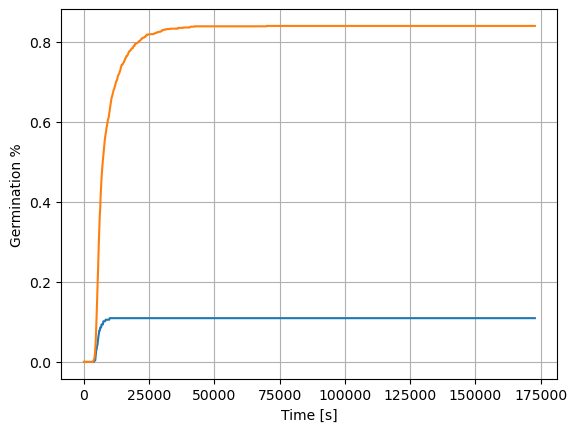

In [12]:
matplotlib.pyplot.close()

fig, ax = subplots()

ax.plot(times, germination[1, :])
ax.plot(times, germination_2)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

## References